In [133]:
from __future__ import annotations

import py3Dmol
from exceptiongroup import catch
# Standard library imports
from pathlib import Path
from datetime import datetime
from typing import Optional, List, Iterable, Tuple, Dict, Any
import os
import re
import logging
import subprocess

# Third-party imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import yaml
import logging as logger
from itables import init_notebook_mode
from rdkit.Chem.Scaffolds.MurckoScaffold import MurckoScaffoldSmiles, MurckoScaffoldSmilesFromSmiles
from useful_rdkit_utils.useful_rdkit_utils import rdMolDescriptors

init_notebook_mode(all_interactive=True)
# ---------------------------------------------------------------------------


In [134]:
from rdkit.Chem import Mol
import itertools
from useful_rdkit_utils import get_largest_fragment
from rdkit.Chem.rdMMPA import FragmentMol
from tqdm import tqdm
from glob import glob

def _parse_sdf_blocks(lines: Iterable[str]) -> Iterable[List[str]]:
    """Yield SDF molecule blocks (list of lines) delimited by '$$$$'."""
    buf: List[str] = []
    for line in lines:
        if line.strip() == "$$$$":
            if buf:
                yield buf
                buf = []
        else:
            buf.append(line.rstrip("\n"))
    if buf:
        # Some SDFs may not end with '$$$$'
        yield buf

def extract_mol_blocks_from_list(mol_lines):
    """
    Extracts the atom and bond blocks from a list of strings representing a MOL file.

    Args:
        mol_lines (list): A list of strings, where each string is a line from the MOL file.

    Returns:
        tuple: A tuple containing the atom_block and bond_block as strings.
    """
    # Join the list of strings into a single multi-line string
    mol_file_content = '\n'.join(mol_lines)

    # Find the line with atom and bond counts
    lines = mol_file_content.strip().split('\n')
    try:
        temp_header_line = [line for line in lines if line.strip().endswith('V2000')][0]
        parts = temp_header_line.split()
        num_atoms = int(parts[0])
        num_bonds = int(parts[1])
    except (IndexError, ValueError):
        raise ValueError("Could not parse atom and bond counts from the MOL file header.")

    # Find the start of the atom and bond blocks
    start_of_data = lines.index(temp_header_line) + 1

    # Extract the atom block
    atom_block_end = start_of_data + num_atoms
    # print(lines[start_of_data:atom_block_end])
    atom_block = "\n".join(lines[start_of_data:atom_block_end])

    # Extract the bond block
    bond_block_end = atom_block_end + num_bonds
    temp_mol_block = '\n'.join(lines[start_of_data:bond_block_end])
    # print(temp_mol_block)

    # print(atom_block, bond_block)
    return temp_header_line, temp_mol_block

def _parse_sdf_properties(block: List[str]) -> Dict[str, Any]:
    """
    Extract property fields from an SDF molecule block. Coordinates are ignored.
    Returns a dict of property_name -> value (string).
    """
    props: Dict[str, Any] = {}
    coords = ""
    # Properties start at lines with '> <Name>'
    i = 0
    n = len(block)
    while i < n:
        line = block[i]
        if line.startswith(">"):
            m = re.match(r">+\s*<([^>]+)>", line)
            if m:
                key = m.group(1).strip()
                i += 1
                values: List[str] = []
                # Read until empty line or next property header
                while i < n and not block[i].startswith(">") and block[i].strip() != "":
                    values.append(block[i])
                    i += 1
                props[key] = "\n".join(values).strip()
                continue
        i += 1
    # props['header_line'], props['mol_block'] = extract_mol_blocks_from_list(block)
    return props


def sdf_to_csv(sdf_file: str | os.PathLike) -> pd.DataFrame:
    """
    Convert an SDF file to a pandas DataFrame by extracting property blocks.
    Writes a CSV next to the input with the same stem.

    Notes
    -----
    - This parser does not extract atom/bond coordinates; it focuses on SDF data fields.
    - If a property appears multiple times across molecules, columns will be unioned.
    """
    sdf_path = Path(sdf_file)
    if not sdf_path.exists():
        raise FileNotFoundError(sdf_path)
    headers, mol_blocks = [], []
    records: List[Dict[str, Any]] = []
    with sdf_path.open("r", encoding="utf-8", errors="ignore") as f:
        for block in _parse_sdf_blocks(f):
            props = _parse_sdf_properties(block)
            records.append(props)
            header, mol_block = extract_mol_blocks_from_list(block)
            headers.append(header)
            mol_blocks.append(mol_block)

    if not records:
        logger.warning("No molecule records parsed from SDF: %s", sdf_path)

    df = pd.DataFrame.from_records(records)
    df['header_line'] = headers
    df['mol_block'] = mol_blocks
    df['filename'] = [sdf_path.name] *  len(df)
    df['local_index'] = df.index
    out_csv = sdf_path.with_suffix(".csv")
    # df.to_csv(out_csv, index=False)
    logger.info("Parsed %d molecules from %s -> %s", len(df), sdf_path.name, out_csv.name)
    return df


import textwrap

def create_sdf_from_blocks(header_line:str, mol_block:str, filename="output_reconstructed.sdf"):
    """
    Reconstructs a MOL file from atom and bond blocks and saves it as an SDF file.

    Args:

        filename (str): The name of the output SDF file.
        :param mol_block:
        :param header_line:
    """
    mol_data = (mol_block)

    # Assemble the full MOL file content
#    RDKit          3D

    mol_content = f"""
{header_line}
{mol_data}
M  END
"""
    # SDF format requires the $$$$ delimiter at the end of each record
    sdf_content = textwrap.dedent(mol_content)
    # sdf_content = textwrap.dedent(mol_content).strip() + "\n$$$$\n"

    try:
        with open(filename, "w") as f:
            f.write(sdf_content)
        print(f"SDF file '{filename}' created successfully from the provided blocks.")
    except IOError as e:
        print(f"An error occurred while writing the file: {e}")

from rdkit import Chem
global_sdf_df = pd.DataFrame()
outputResults = pd.read_csv("/home/a/REINVENT4/ReinventStudies/pleaseWork/justmol2mol_4_Compounds/graph-dock/node-reinvent/justmol2mol_4__1.csv", header=0)

sdfFiles ="/home/a/REINVENT4/ReinventStudies/scoringData/dockedData/justmol2mol_4_compounds_Mols"
# outputResults.head()
for file in glob(f"{sdfFiles}*.sdf"):
    sdf_df = sdf_to_csv(file)
    # sdf_df['file'] = Path(file).stem
    mols = Chem.MolToMolBlock(Chem.SDMolSupplier(file)[0])
    # print(mols)
    # print(mols.GetItemText(2))
    global_sdf_df = pd.concat([global_sdf_df, sdf_to_csv(file)], ignore_index=True)


def cleanup_fragment(mol: Mol) -> Tuple[Mol, int]:
    """
    Replace atom map numbers with Hydrogens
    :param mol: input molecule
    :return: modified molecule, number of R-groups
    """
    rgroup_count = 0
    for atm in mol.GetAtoms():
        atm.SetAtomMapNum(0)
        if atm.GetAtomicNum() == 0:
            rgroup_count += 1
            atm.SetAtomicNum(1)
    mol = Chem.RemoveAllHs(mol)
    return mol, rgroup_count



def generate_fragments(mol: Mol) -> pd.DataFrame:
    """
    Generate fragments using the RDKit
    :param mol: RDKit molecule
    :return: a Pandas dataframe with Scaffold SMILES, Number of Atoms, Number of R-Groups
    """
    # Generate molecule fragments
    frag_list = FragmentMol(mol)
    # Flatten the output into a single list
    flat_frag_list = [x for x in itertools.chain(*frag_list) if x]
    # The output of Fragment mol is contained in single molecules.  Extract the largest fragment from each molecule
    flat_frag_list = [get_largest_fragment(x) for x in flat_frag_list]
    # Keep fragments where the number of atoms in the fragment is at least 2/3 of the number fragments in
    # input molecule
    num_mol_atoms = mol.GetNumAtoms()
    flat_frag_list = [x for x in flat_frag_list if x.GetNumAtoms() / num_mol_atoms > 0.67]
    # remove atom map numbers from the fragments
    flat_frag_list = [cleanup_fragment(x) for x in flat_frag_list]
    # Convert fragments to SMILES
    frag_smiles_list = [[Chem.MolToSmiles(x), x.GetNumAtoms(), y] for (x, y) in flat_frag_list]
    # Add the input molecule to the fragment list
    frag_smiles_list.append([Chem.MolToSmiles(mol), mol.GetNumAtoms(), 1])
    # Put the results into a Pandas dataframe
    frag_df = pd.DataFrame(frag_smiles_list, columns=["Scaffold", "NumAtoms", "NumRgroupgs"])
    # Remove duplicate fragments
    frag_df = frag_df.drop_duplicates("Scaffold")
    return frag_df

def find_scaffolds(df_in: pd.DataFrame, smiles_col="SMILES", name_col="Name",disable_progress=False) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Generate scaffolds for a set of molecules
    :param df_in: Pandas dataframe with [SMILES, Name, RDKit molecule] columns
    :return: dataframe with molecules and scaffolds, dataframe with unique scaffolds
    """
    # Loop over molecules and generate fragments, fragments for each molecule are returned as a Pandas dataframe
    df_list = []
    for smiles, name in tqdm(df_in[[smiles_col, name_col]].values, disable=disable_progress):
        tmp_df = generate_fragments(Chem.MolFromSmiles(smiles)).copy()
        tmp_df['Name'] = name
        tmp_df[smiles_col] = smiles
        df_list.append(tmp_df)
    # Combine the list of dataframes into a single dataframe
    mol_df = pd.concat(df_list)
    # Collect scaffolds
    scaffold_list = []
    for k, v in mol_df.groupby("Scaffold"):
        scaffold_list.append([k, len(v.Name.unique()), v.NumAtoms.values[0]])
    scaffold_df = pd.DataFrame(scaffold_list, columns=["Scaffold", "Count", "NumAtoms"])
    # Any fragment that occurs more times than the number of fragments can't be a scaffold
    num_df_rows = len(df_in)
    scaffold_df = scaffold_df.query("Count <= @num_df_rows")
    # Sort scaffolds by frequency
    scaffold_df = scaffold_df.sort_values(["Count", "NumAtoms"], ascending=[False, False])
    return mol_df, scaffold_df

# scaffoldDataTuple = find_scaffolds(df_in= global_sdf_df, smiles_col="smiles")
for i, row in global_sdf_df.iterrows():
    global_sdf_df.at[i,'MurckoScaffold']= MurckoScaffoldSmilesFromSmiles(row['smiles'])
# global_sdf_df['Name']= global_sdf_df.index()



# scaffoldDataTuple[0].smiles = scaffoldDataTuple[0].SMILES

# pd.merge(inner_join_df, scaffoldDataTuple[0], on=['Name','smiles'], how='inner')
# pd.merge(inner_join_df, scaffoldDataTuple[1], on=['Name','smiles'], how='inner')

global_sdf_df.head()



Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [135]:
global_sdf_df['rmsd'] = global_sdf_df['rmsd'].astype(float)
global_sdf_df['energy'] = global_sdf_df['energy'].astype(float)

# scaffoldDF['MurckoScaffold']= global_sdf_df['MurckoScaffold'].unique()

grouped = global_sdf_df.groupby("MurckoScaffold").agg(
    total_count=pd.NamedAgg(column="MurckoScaffold", aggfunc="count"),
    mean_energy=pd.NamedAgg(column="energy", aggfunc="mean"),
    std_energy=pd.NamedAgg(column="energy", aggfunc="std"),
    mean_rmsd=pd.NamedAgg(column="rmsd", aggfunc="mean"),
    std_rmsd=pd.NamedAgg(column="rmsd", aggfunc="std")
)


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [237]:
# def compute_metrics(x):
#
#     result = {
#             "count": x["MurckoScaffold"].count(),
#             "mean_energy": x["energy"].mean(),
#             "mean_rmsd": x["rmsd"].mean(),
#             "std_energy": x["energy"].std(),
#             "std_rmsd": x["rmsd"].std(),
#             "std_e_energy": x["energy"].std()/x["MurckoScaffold"].count(),
#             "std_e_rmsd":x["energy"].std()/x["MurckoScaffold"].count(),
# }
#
#     return pd.Series(result)

# result = global_sdf_df.groupby("MurckoScaffold").apply(compute_metrics, include_groups=False)

resultsAll = global_sdf_df[["MurckoScaffold","energy","rmsd"]]

result= pd.DataFrame()
# result['MurckoScaffold'] = grouped.index
# result.set_index(len())
result["total_count"] = grouped.total_count
result["mean_energy"] = grouped.mean_energy
result["std_energy"] = grouped.std_energy
result["mean_rmsd"] = grouped.mean_rmsd
result["std_rmsd"] = grouped.std_rmsd

result["std_e_energy"] = result["std_energy"]/ np.sqrt(result["total_count"])
result["std_e_rmsd"] = result["std_rmsd"]/ np.sqrt(result["total_count"])

# result['MurckoScaffold'] = grouped.index

# result["std_e_energy"] = result["std_energy"] / np.sqrt(result["count"])
# result["std_e_rmsd"] = result["std_rmsd"] / np.sqrt(result["count"])
result
# grouped["C"].agg([lambda x: x.max() - x.min()
#
#
# ts.groupby(lambda x: x.year).transform(lambda x: x.max() - x.min())
# Out[143]:
# 2000-01-08    0.623893
# 2000-01-09    0.623893
# 2000-01-10    0.623893
# 2000-01-11    0.623893
# 2000-01-12    0.623893
#                 ...
# 2002-09-30    0.558275
# 2002-10-01    0.558275
# 2002-10-02    0.558275
# 2002-10-03    0.558275
# 2002-10-04    0.558275
# Freq: D, Length: 1001, dtype: float64
#
# global_sdf_df['MurckoScaffold',"energy","rmsd"]
#     df.groupby('A').agg('min')
#     global_sdf_df.groupby(["MurckoScaffold"])["energy"].mean()
# #
# global_sdf_df['team_count'] = global_sdf_df.groupby('MurckoScaffold')['MurckoScaffold'].transform('count')
# scaffoldDF['MurckoScaffold'] = global_sdf_df['MurckoScaffold'].unique()
# scaffoldDF['count'] = global_sdf_df.groupby('MurckoScaffold')['MurckoScaffold'].transform('count')
# scaffoldDF['mean_rmsd'] = global_sdf_df.groupby('MurckoScaffold')['rmsd'].transform('mean')
# scaffoldDF['mean_energy'] = global_sdf_df.groupby('MurckoScaffold')['energy'].transform('mean')
#
#
# scaffoldDF['mean_rmsd'] =global_sdf_df.groupby('MurckoScaffold')['rmsd'].mean(numeric_only=True)
# scaffoldDF['mean_energy'] =global_sdf_df.groupby('MurckoScaffold')['energy'].mean()

result = result.sort_values(by=["mean_energy"],ascending=True, )
result.reset_index(inplace=True)
result.reset_index(inplace=True)
result
resultsAll

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


/tmp/ipykernel_4489/644700230.py:8: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



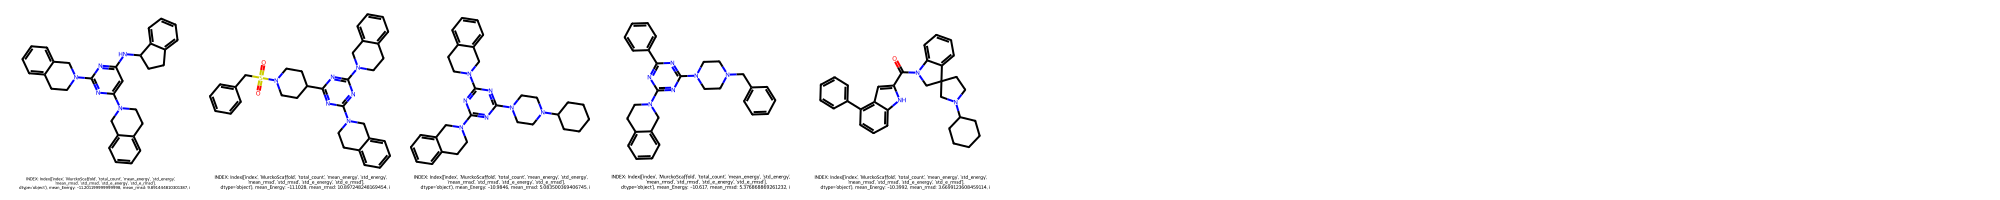

In [247]:

import plotly.graph_objects as go
from rdkit.Chem.Draw import IPythonConsole, MolsToGridImage



testDataSet = result.head(5)

testDataSet['mol'] = testDataSet['MurckoScaffold'].apply(Chem.MolFromSmiles)
# min_value = data.groupby('A').B.min()
img = MolsToGridImage(
    testDataSet['mol'],
    molsPerRow=10,
    maxMols=80,
    legends=[f" INDEX: {row.index}, mean_Energy: {row['mean_energy']}, mean_rmsd: {row['mean_rmsd']}, i" for _, row in result.iterrows()], useSVG=False,
returnPNG=True)





fig = go.Figure()
fig.add_trace( (go.Violin(x=resultsAll.index, y= resultsAll.energy)))


fig.show()
img
# ax.errorbar(testDataSet.index, (testDataSet["mean_energy"]),(testDataSet["std_e_energy"]),  linestyle='None', marker='^')
#
# fig.align_xlabels(range(len(testDataSet)))
# # plt.errorbar(testDataSet["MurckoScaffold"], testDataSet["mean_rmsd"],testDataSet["std_e_rmsd"] ,  linestyle='None', marker='x')
# plt.show()


In [138]:

uniqueStructs = global_sdf_df['smiles'].unique()
# minima = pd.DataFrame()
minima = pd.DataFrame(columns=['name',"smiles", "rmsd","energy"])

for smile in uniqueStructs:
    min_RMSD = global_sdf_df[global_sdf_df['smiles'] == smile]['rmsd'].min()
    min_energy = global_sdf_df[global_sdf_df['smiles'] == smile]['energy'].min()

    energy = global_sdf_df[(global_sdf_df['smiles'] == smile) & (global_sdf_df['rmsd'] == min_RMSD)]['energy'].min()
    # header_line = global_sdf_df[(global_sdf_df['smiles'] == smile) & (global_sdf_df['rmsd'] == min_RMSD)]['header_line']
    # mol_block = global_sdf_df[(global_sdf_df['smiles'] == smile) & (global_sdf_df['rmsd'] == min_RMSD)]['mol_block']

    minima.loc[len(minima)] = {'smiles':smile,'rmsd':min_RMSD, 'energy':energy}
        # , "header_line":header_line, 'mol_block':mol_block}
minima.reset_index(drop=True, inplace=True)
inner_join_df= pd.merge(minima, global_sdf_df, on=["smiles", "rmsd","energy"], how='inner')
inner_join_df['energy'] = inner_join_df['energy'].astype(float)
inner_join_df['rmsd'] = inner_join_df['rmsd'].astype(float)


# minima.atom_block = minima.atom_block.astype(str)
# minima.bond_block = minima.bond_block.astype(str)

In [139]:

for i, row in inner_join_df.iterrows():
    filename=f"{sdfFiles}-re_minima_{i}.mol"
    filename_sdf=f"{sdfFiles}-re_minima_{i}.sdf"

    basePath = "/home/a/REINVENT4/ReinventStudies/scoringData/dockedData/"

    mol_data_local = Chem.MolToMolBlock(Chem.SDMolSupplier(basePath+row['filename'],removeHs=False)[row['local_index']])
    inner_join_df.at[i,'mol_data_local'] = mol_data_local
    m2h = Chem.MolFromMolBlock(mol_data_local)
    inner_join_df.at[i,'m2h'] =m2h


    from openbabel import pybel

    # Load the MOL file
    mol = next(pybel.readfile("mol", filename))

    # Write to MOL2 format
    mol.write("mol2", filename.replace(".mol",".mol2"),overwrite=True)

    inner_join_df.at[i,'pdb'] =filename.replace(".mol",".pdb")
    Chem.MolToPDBFile(m2h, filename.replace(".mol",".pdb"))

    if row['mol_block']  in mol_data_local:
        continue
    else:
        break
        print("ERROR")
    with open(f"{filename}", "w") as f:
        f.write(mol_data_local)
    f.close()
# print(glob(f"{sdfFiles}-re_minima*"))

    # # print(row['atom_block'])
    # create_sdf_from_blocks(row.header_line, row.mol_block, filename=f"{sdfFiles}-minima_{i}.mol")
inner_join_df["Mean_Scaffold_energy"] = inner_join_df.groupby(['MurckoScaffold'])['energy'].mean()

inner_join_df["Mean_Scaffold_rmsd"] = inner_join_df.groupby(['MurckoScaffold'])['rmsd'].mean()


def getMolDescriptors(mol, missingVal=None):
    ''' calculate the full list of descriptors for a molecule

        missingVal is used if the descriptor cannot be calculated
    '''
    res = {}
    for nm,fn in Descriptors._descList:
        # some of the descriptor fucntions can throw errors if they fail, catch those here:
        try:
            val = fn(mol)
        except:
            # print the error message:
            import traceback
            traceback.print_exc()
            # and set the descriptor value to whatever missingVal is
            val = missingVal
        res[nm] = val
    return res



allDescrs = [getMolDescriptors(m) for m in inner_join_df['m2h']]

inner_join_df.to_csv(f"{sdfFiles}_absolute_minima.csv")
inner_join_df

NameError: name 'Descriptors' is not defined

In [6]:

import py3Dmol
view = py3Dmol.view()
view.removeAllModels()
view.setViewStyle({'style':'outline','color':'black','width':0.1})

view = py3Dmol.view()
    # data=inner_join_df.at[0,'mol_data_local'],  # Convert the RDKit molecule for py3Dmol
    # data=inner_join_df.at[0,'mol_data_local'],  # Convert the RDKit molecule for py3Dmol
style={'stick':{'colorscheme':'greenCarbon','radius':0.2}}

view.addModel(open('../mols/Rad51/rad51Prepped.pdb','r').read(),format='pdb')

Prot=view.getModel()
Prot.setStyle({'cartoon':{'arrows':True, 'tubes':True, 'style':'oval', 'color':'white'}})
view.addSurface(py3Dmol.VDW,{'opacity':0.6,'color':'white'})


view.addModel(open(inner_join_df.at[0,'pdb'],'r').read(),format='pdb')

lig=view.getModel()
lig.setStyle(style)




# view.addModel(open('justmol2mol_4_compounds_Mols-minima_0.mol','r').read(),format='mol')

view.zoomTo()
view.show()
# view.render()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [298]:
import MDAnalysis as mda
from MDAnalysis.coordinates import PDB

import prolif as plf
from prolif.plotting.network import LigNetwork
from IPython.display import IFrame


# load protein
prot = mda.Universe("../mols/Rad51/rad51Prepped.pdb",guess_bonds=True)
prot = plf.Molecule.from_mda(prot)
prot.n_residues

# load ligands
# path = Path(inner_join_df.at[0,'m2h'])
# ligand_mol = plf.Molecule.from_rdkit(path)# generate fingerprint

try:
    pose_iterable_all = [plf.Molecule.from_rdkit(row["m2h"]) for (row) in inner_join_df.iterrows()]
except Exception as e:
    print(f"issue {e}")


try:
    # pose_iterable = plf.mol2_supplier(poses_path)
    # pose_iterable_all = plf.sdf_supplier("/home/a/REINVENT4/ReinventStudies/scoringData/dockedData/justmol2mol_4_compounds_Mols13.sdf")
    fp = plf.Fingerprint(Count= True)
    ifp = fp.generate(pose_iterable_all, prot)
    fp.run_from_iterable(pose_iterable_all, prot)
    results_df = fp.to_dataframe()
    # inner_join_df.at[i,"Docking Results"]=(results_df)
    # inner_join_df.at[i,"fp"]= fp
    # inner_join_df.at[i,"pose_iterable"]=(pose_iterable)

    fp.plot_lignetwork( ligand_mol= pose_iterable_all).save()


    # IFrame(X, width=700, height=350)


except:
    print("Skipping" )




issue tuple indices must be integers or slices, not str
Skipping


In [ ]:

fp.plot_lignetwork( ligand_mol= pose_iterable_all).save()

In [ ]:





fps =[]
dfs=[]
poses=[]
inner_join_df = inner_join_df.sort_values("energy")
for i, row in (inner_join_df.iterrows()):

    poses_path = "/home/a/REINVENT4/ReinventStudies/scoringData/dockedData/"+row['filename']


    # pose_iterable = plf.mol2_supplier(poses_path)

    # path = Path(inner_join_df.at[0,'m2h'])
    # ligand_mol = plf.Molecule.from_rdkit(path)# generate fingerprint
    pose_iterable = plf.sdf_supplier(poses_path)[row['local_index']]

    fp = plf.Fingerprint(count=True)
    fp.to_pickle(row['filename'].replace(".sdf",".pkl"))
    fp.run_from_iterable([pose_iterable], prot)
    results_df = fp.to_dataframe()
    dfs.append(results_df)
    fps.append(fp)
    poses.append(pose_iterable)

    results_df
    # display(fp.plot_lignetwork(pose_iterable, display_all=True))


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [329]:
results_df

Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [323]:
# %matplotlib ipympl
display()
#
# for i, rows in inner_join_df.iterrows():
#
#             rows['fp'].plot_lignetwork(rows['pose_iterable'][0])
x.

In [9]:


selected_df =   outputResults[outputResults['maize (raw)'] <= -9.0]   

selected_df.sort_values('maize (raw)')





Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [18]:
# Plotly combined timeseries (mean ± SE) and histogram plots for Score, maize (raw), QED, Agent with axis labels
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import numpy as np

ordered_vars = ['Score', 'maize (raw)', 'QED', 'Agent']
n_total = len(outputResults)
colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA']

fig = make_subplots(
    rows=2, cols=4,
    subplot_titles=[f"{v}" for v in ordered_vars] + [f"{v}" for v in ordered_vars],
    vertical_spacing=0.15
)

if 'step' in outputResults.columns:
    for i, var in enumerate(ordered_vars):
        if var in outputResults.columns:
            # Timeseries (mean ± SE)
            grouped = outputResults.groupby('step')[var]
            mean = grouped.mean()
            stderr = grouped.sem()
            fig.add_trace(
                go.Scatter(
                    x=mean.index,
                    y=mean.values,
                    mode='lines+markers',
                    name=f'{var} (mean)',
                    marker_color=colors[i],
                    error_y=dict(
                        type='data',
                        array=stderr.values,
                        visible=True,
                        color=colors[i],
                        thickness=1.5
                    ),
                    showlegend=False
                ),
                row=1, col=i+1
            )
            # Histogram
            fig.add_trace(
                go.Histogram(
                    x=outputResults[var],
                    nbinsx=30,
                    marker_color=colors[i],
                    opacity=0.8,
                    name=var,
                    showlegend=False
                ),
                row=2, col=i+1
            )
            # Add axis labels
            fig.update_xaxes(title_text='Step', row=1, col=i+1)
            fig.update_yaxes(title_text=var, row=1, col=i+1)
            fig.update_xaxes(title_text=var, row=2, col=i+1)
            fig.update_yaxes(title_text='Frequency', row=2, col=i+1)
    # Add minor ticks and grids
    for row in [1, 2]:
        for col in range(1, 5):
            fig.update_xaxes(
                row=row, col=col,
                showgrid=True, gridwidth=1, gridcolor='rgba(200,200,200,0.3)',
                minor=dict(ticks='outside', showgrid=True, gridwidth=0.5, gridcolor='rgba(220,220,220,0.2)')
            )
            fig.update_yaxes(
                row=row, col=col,
                showgrid=True, gridwidth=1, gridcolor='rgba(200,200,200,0.3)',
                minor=dict(ticks='outside', showgrid=True, gridwidth=0.5, gridcolor='rgba(220,220,220,0.2)')
            )
    fig.update_layout(
        title={
            'text': '<b>Score, maize (raw), QED, Agent: Timeseries and Distributions</b>',
            'x':0.5,
            'xanchor': 'center',
            'font': {'size': 22}
        },
        template='plotly_white',
        font=dict(size=16),
        height=780,
        width=1200,
        margin=dict(t=80, b=60, l=60, r=60),
        plot_bgcolor='rgba(245,245,255,1)',
        paper_bgcolor='rgba(245,245,255,1)'
    )
    fig.show()
else:
    print("The column 'step' is not present in outputResults.")

In [19]:
# Plotly histograms for Score, maize (raw), QED for top 5% lowest maize (raw) and top 5% highest Score, with axis labels
import plotly.graph_objs as go
from plotly.subplots import make_subplots

n_rows = len(outputResults)
top_pct = 0.05
n_top = max(1, int(n_rows * top_pct))

# Dataset 1: Top 5% by lowest maize (raw)
if 'maize (raw)' in outputResults.columns:
    lowest_maize_df = outputResults.nsmallest(n_top, 'maize (raw)')
else:
    lowest_maize_df = outputResults.copy()

# Dataset 2: Top 5% by highest Score
if 'Score' in outputResults.columns:
    highest_score_df = outputResults.nlargest(n_top, 'Score')
else:
    highest_score_df = outputResults.copy()

for subset_name, df in zip([
    "Top 5% Lowest maize (raw)",
    "Top 5% Highest Score"
], [lowest_maize_df, highest_score_df]):
    fig = make_subplots(rows=1, cols=3, subplot_titles=[
        "Score", "maize (raw)", "QED"
    ])
    ordered_vars = ['Score', 'maize (raw)', 'QED']
    colors = ['#636EFA', '#EF553B', '#00CC96']
    for i, var in enumerate(ordered_vars):
        if var in df.columns:
            fig.add_trace(
                go.Histogram(
                    x=df[var],
                    nbinsx=30,
                    marker_color=colors[i],
                    opacity=0.8,
                    name=var,
                    showlegend=False
                ),
                row=1, col=i+1
            )
            # Add axis labels
            fig.update_xaxes(title_text=var, row=1, col=i+1)
            fig.update_yaxes(title_text='Frequency', row=1, col=i+1)
    fig.update_layout(
        title={
            'text': f"<b>{subset_name}</b>",
            'x':0.5,
            'xanchor': 'center',
            'font': {'size': 22}
        },
        template='plotly_white',
        bargap=0.15,
        font=dict(size=16),
        height=500,
        width=1200
    )
    # Add minor ticks and grids
    for i in range(1, 4):
        fig.update_xaxes(
            row=1, col=i,
            showgrid=True, gridwidth=1, gridcolor='rgba(200,200,200,0.3)',
            minor=dict(ticks='outside', showgrid=True, gridwidth=0.5, gridcolor='rgba(220,220,220,0.2)')
        )
        fig.update_yaxes(
            row=1, col=i,
            showgrid=True, gridwidth=1, gridcolor='rgba(200,200,200,0.3)',
            minor=dict(ticks='outside', showgrid=True, gridwidth=0.5, gridcolor='rgba(220,220,220,0.2)')
        )
    fig.update_traces(marker_line_width=1.5)
    fig.show()

In [20]:
# Plotly violin plots comparing top 5% subsets to the main dataset for Score, maize (raw), QED (side-by-side, not overlaid)
import plotly.graph_objs as go
from plotly.subplots import make_subplots

main_df = outputResults.copy()
main_df['subset'] = 'All'
lowest_maize_df['subset'] = 'Top 5% Lowest maize (raw)'
highest_score_df['subset'] = 'Top 5% Highest Score'

compare_df = pd.concat([
    main_df,
    lowest_maize_df,
    highest_score_df
], ignore_index=True)

plot_vars = ['Score', 'maize (raw)', 'QED']
colors = ['#636EFA', '#EF553B', '#00CC96']

fig = make_subplots(rows=1, cols=3, subplot_titles=[f"{v}" for v in plot_vars])

for i, var in enumerate(plot_vars):
    if var in compare_df.columns:
        for j, subset in enumerate(['All', 'Top 5% Lowest maize (raw)', 'Top 5% Highest Score']):
            fig.add_trace(
                go.Violin(
                    y=compare_df[compare_df['subset'] == subset][var],
                    x=[subset]*len(compare_df[compare_df['subset'] == subset][var]),
                    name=subset,
                    line_color=colors[j],
                    box_visible=False,
                    meanline_visible=True,
                    showlegend=(i==0),
                    opacity=0.7,
                    width=0.6,
                    side='both',
                    spanmode='hard'
                ),
                row=1, col=i+1
            )
        # Add axis labels
        # fig.update_xaxes(title_text='Subset', row=1, col=i+1)
        fig.update_yaxes(title_text=var, row=1, col=i+1)

# Make all images the same size and presentation ready
fig.update_layout(
    title={
        'text': '<b>Comparison of Subsets to Main Dataset: Violin Plots</b>',
        'x':0.5,
        'xanchor': 'center',
        'font': {'size': 24}
    },
    template='plotly_white',
    font=dict(size=18),
    height=500,
    width=1500,
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='center',
        x=0.5,
        font=dict(size=16)
    ),
    margin=dict(t=80, b=60, l=60, r=60),
    plot_bgcolor='rgba(245,245,255,1)',
    paper_bgcolor='rgba(245,245,255,1)'
)
# Add minor ticks and grids
for col in [1, 2, 3]:
    fig.update_xaxes(
        row=1, col=col,
        showgrid=True, gridwidth=1, gridcolor='rgba(200,200,200,0.3)',
        minor=dict(ticks='outside', showgrid=True, gridwidth=0.5, gridcolor='rgba(220,220,220,0.2)')
    )
    fig.update_yaxes(
        row=1, col=col,
        showgrid=True, gridwidth=1, gridcolor='rgba(200,200,200,0.3)',
        minor=dict(ticks='outside', showgrid=True, gridwidth=0.5, gridcolor='rgba(220,220,220,0.2)')
    )
fig.show()

In [21]:

lowest_maize_df = lowest_maize_df.sort_values(by='maize (raw)', ascending=True)
highest_score_df = highest_score_df.sort_values(by='Score', ascending=True)

cam833Input = "COc1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)CNC(=O)c2ccc3cc(F)ccc3n2)c(Cl)c1"
Cam833_lowest_maize_df = lowest_maize_df[lowest_maize_df['Input_SMILES'] == cam833Input]
Cam833_highest_score_df = highest_score_df[highest_score_df['Input_SMILES'] == cam833Input]

scoringDF = pd.DataFrame()
scoringDF = pd.concat([scoringDF, Cam833_lowest_maize_df[:100], Cam833_highest_score_df[:100],], ignore_index=True)
scoringDF = pd.concat([scoringDF, lowest_maize_df[:100], highest_score_df[:100],], ignore_index=True)

scoringDF.drop_duplicates(subset=['SMILES'], inplace=True)
scoringDF.dropna()

scoringDF.reset_index(drop=True, inplace=True)

with open("../scoringData/smilesToScore.smi", "w") as file:
    for smi in scoringDF['SMILES']:
        print(smi)
        file.write(f"{smi}\n")

# scoringDF['SMILES']
    

O=C(NCC(=O)N1CCC[C@H]1C(=O)N[C@H]1CC[C@H](Oc2ncccn2)CC1)c1ccc2cc(F)ccc2n1
O=C(NCC(=O)N1CCCC[C@H]1C(=O)NCc1ccc(-c2ccncc2)cc1)c1ccc2ccccc2n1
O=C(NCC(=O)N1C[C@H](O)C[C@H]1CN1CC[C@H](c2ccccc2)C1)c1ccc2cc(F)ccc2n1
O=C(NCC(=O)N1CCCC1c1ccc(-c2ccccc2)cc1)c1nccc2ccccc12
CN(CCNC(=O)c1ccc2cc(F)ccc2n1)C(=O)[C@H]1C[C@H](O)CN1S(=O)(=O)c1ccccc1
O=C(NCC(=O)N1CCC[C@@H]1c1ncc([C@H]2CCCC[C@@H]2C2CCCCC2)o1)c1ccc2cc(F)ccc2n1
COC[C@H]1C[C@H](C(=O)Nc2ccccc2)N(C(=O)CNC(=O)c2ccc3ccccc3n2)C1
O=C(NCC(=O)N1CCC[C@H]1CNc1ccc(-c2cnccn2)cc1)c1ccc2cc(F)ccc2n1
O=C(NCC(=O)N1CCC[C@H]1CN1CCC(c2ccccc2)CC1)c1ccc2ccccc2n1
N[C@H]1C[C@@H](C(=O)N2CC[C@H](c3ccccc3)C2)N(C(=O)CNC(=O)c2ccc3cccnc3n2)C1
CC(C)C[C@H](NC(=O)c1ccc2ccccc2n1)C(=O)CNC(=O)c1ccc2ccccc2n1
O=C(NCC(=O)N1C[C@H](O)C[C@H]1Cc1cccc2ccccc12)c1ccc2ccccc2n1
O=C(NCC(=O)N1CCC[C@H]1CNCc1ccc(-c2ncc[nH]2)cc1)c1ccc2cc(F)ccc2n1
CC(C)C[C@@H](NC(=O)c1ccc2ccccc2n1)[C@H](O)CNC(=O)c1ccc2ccccc2c1
O=C(NCC(=O)N1CC[C@H](O)[C@H]1Cc1cccc(-c2ccccn2)c1)c1ccc2cc(F)ccc2n1
C[C@@H](NC(=O)C1CCC

Total Length of all REINVENT csvs 15612


/home/a/miniconda3/envs/maize-dev/lib/python3.10/site-packages/rdkit/Chem/Draw/IPythonConsole.py:261: UserWarning:

Truncating the list of molecules to be displayed to 80. Change the maxMols value to display more.



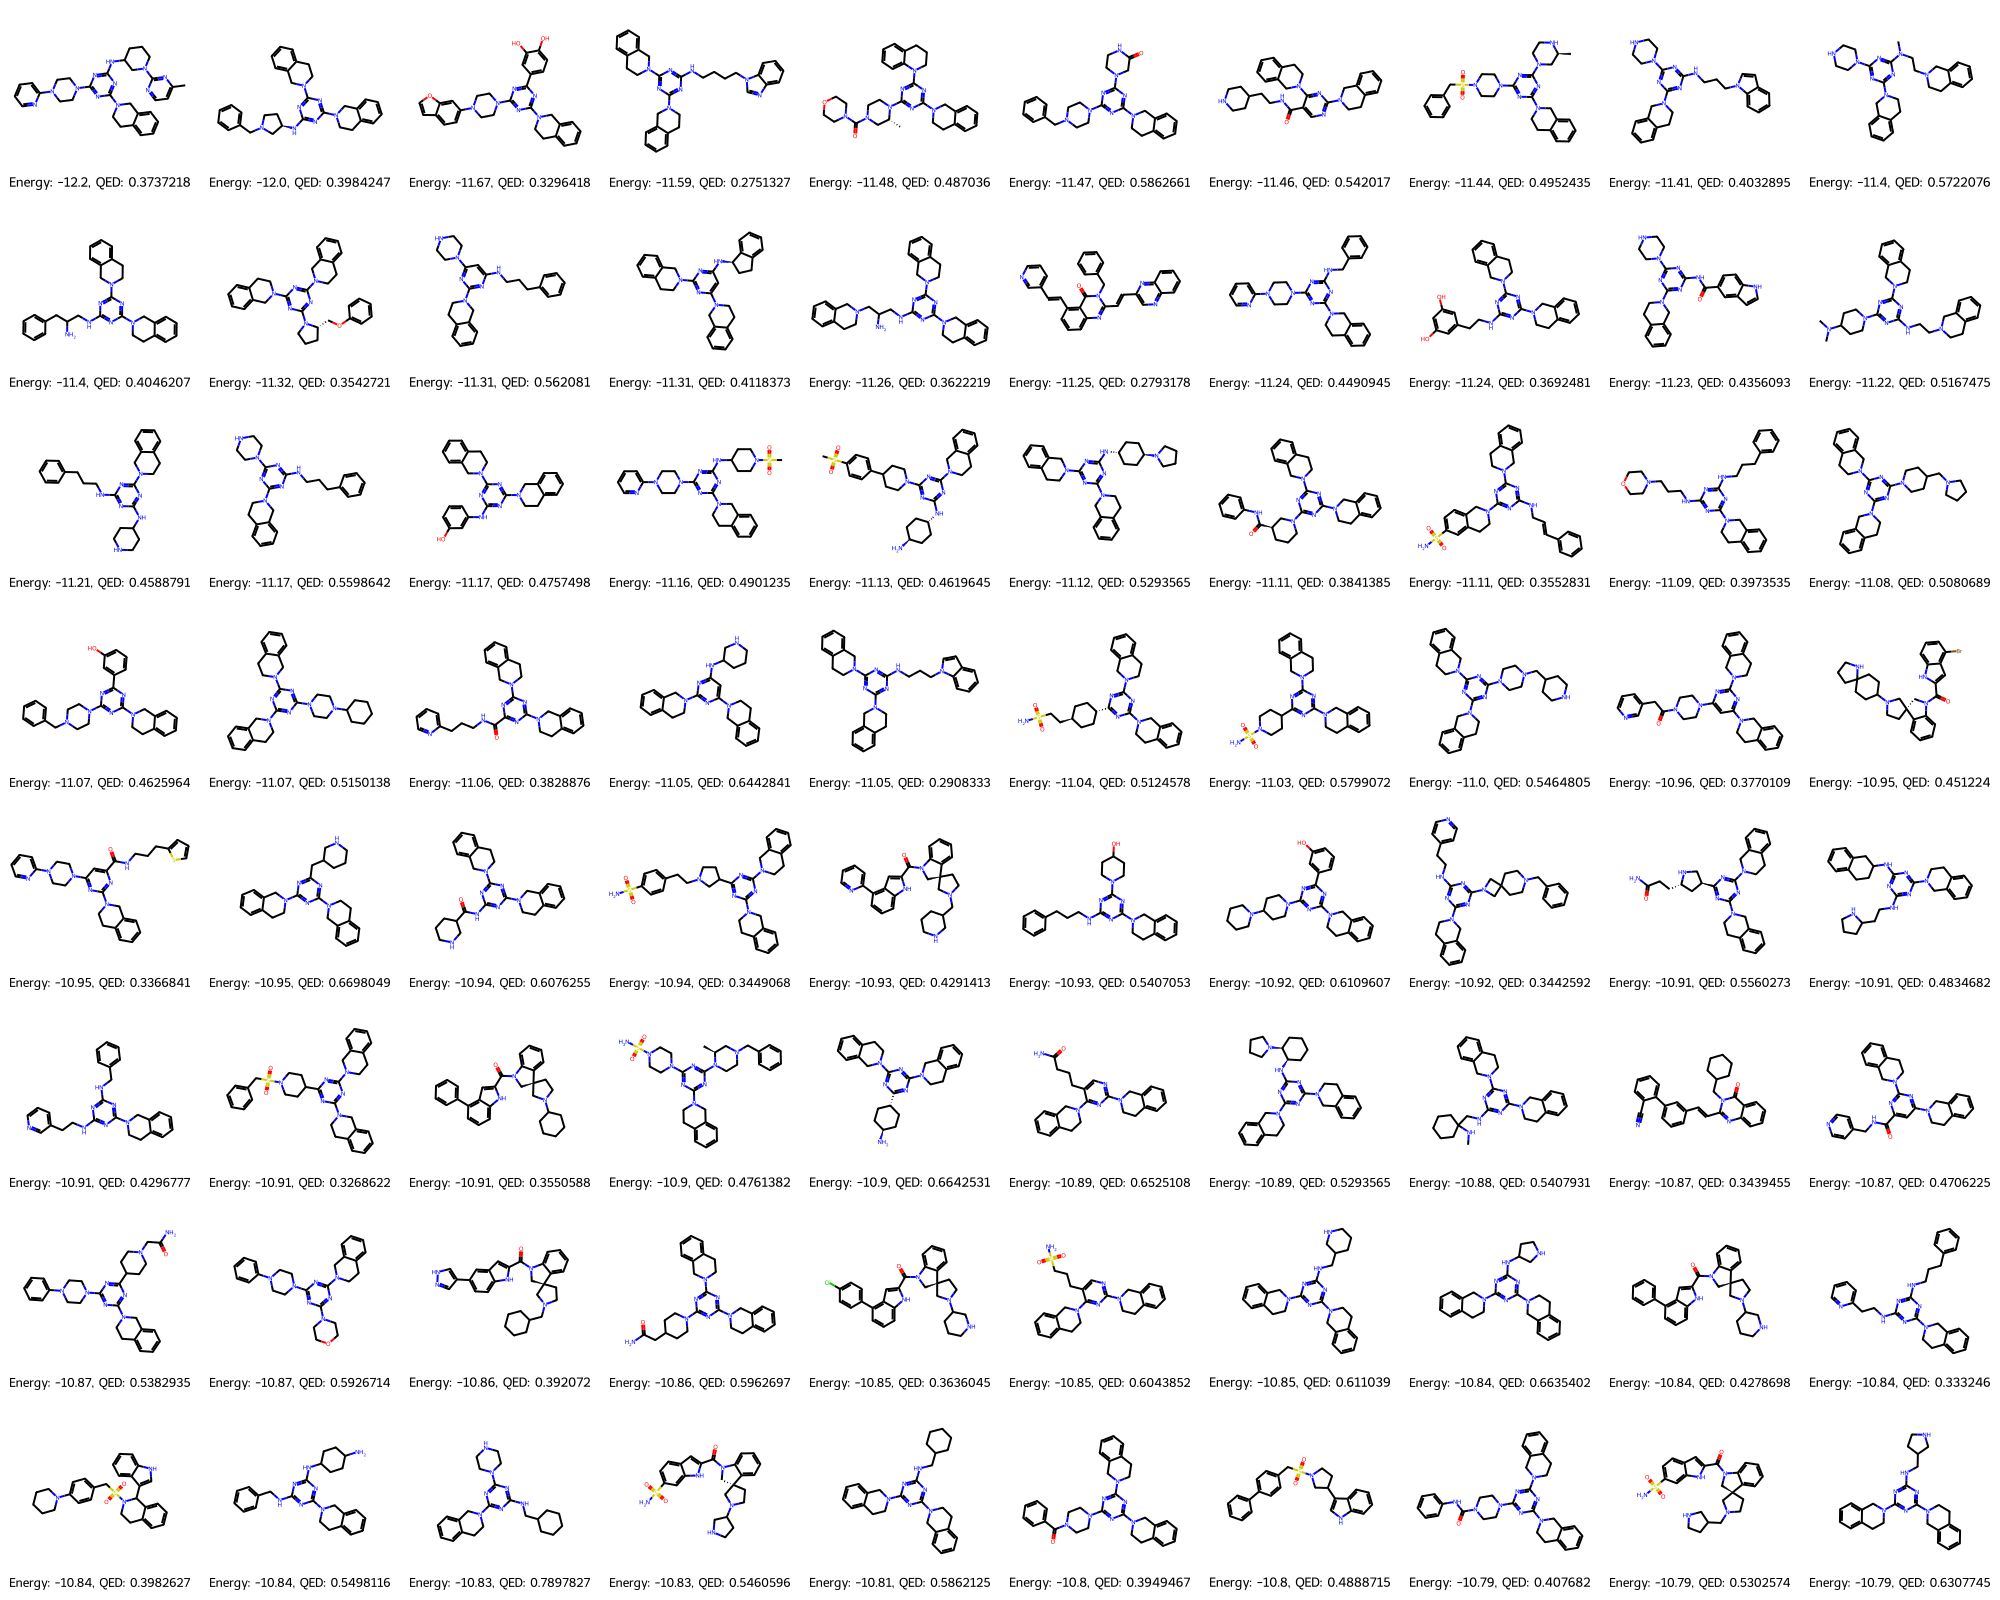

In [22]:
logger = logging.getLogger(__name__)
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import IPythonConsole, MolsToGridImage
from IPython.display import display, update_display

# The next line is commented out 
# because GitHub does not render svg's embedded in notebooks
IPythonConsole.ipython_useSVG=True

# 
# 
# 
# (f"Total Length of all Uniqye SDFs {len(global_sdf_df['SMILES'].unique())}")

print(f"Total Length of all REINVENT csvs {len(outputResults['SMILES'].unique())}")



lowest_maize_df = lowest_maize_df.sort_values(by='maize (raw)', ascending=True)

from PIL import Image
from io import BytesIO
def show_mol(d2d,mol,legend='',highlightAtoms=[]):
    d2d.DrawMolecule(mol,legend=legend, highlightAtoms=highlightAtoms)
    d2d.FinishDrawing()
    bio = BytesIO(d2d.GetDrawingText())
    return Image.open(bio)
def show_images(imgs,buffer=5):
    height = 0
    width = 0
    for img in imgs:
        height = max(height,img.height)
        width += img.width
    width += buffer*(len(imgs)-1)
    res = Image.new("RGBA",(width,height))
    x = 0
    for img in imgs:
        res.paste(img,(x,0))
        x += img.width + buffer
    return res


substructures = pd.DataFrame()

substructures = pd.concat([substructures, lowest_maize_df.head(100)], ignore_index=True)
substructures = pd.concat([substructures, highest_score_df.head(100)], ignore_index=True)
substructures = substructures.dropna()
substructures = substructures.drop_duplicates(subset=['SMILES']).reset_index(drop=True)

cam833Input = "COc1ccc([C@H](C)NC(=O)[C@@H]2C[C@@H](O)CN2C(=O)CNC(=O)c2ccc3cc(F)ccc3n2)c(Cl)c1"
Cam833_lowest_maize_df = lowest_maize_df[lowest_maize_df['Input_SMILES'] == cam833Input]
Cam833_highest_score_df = highest_score_df[highest_score_df['Input_SMILES'] == cam833Input]

if not Cam833_lowest_maize_df.empty:
    substructures = pd.concat([substructures, Cam833_lowest_maize_df.head(20)], ignore_index=True)
    substructures = substructures.drop_duplicates(subset=['SMILES']).reset_index(drop=True)

if not Cam833_highest_score_df.empty:
    substructures = pd.concat([substructures, Cam833_highest_score_df.head(20)], ignore_index=True)
    substructures = substructures.drop_duplicates(subset=['SMILES']).reset_index(drop=True)

substructures = substructures.drop_duplicates()
substructures = substructures.sort_values(by='maize (raw)', ascending=True).reset_index(drop=True)
substructures['mol'] = substructures['SMILES'].apply(Chem.MolFromSmiles)
# min_value = data.groupby('A').B.min()
img = MolsToGridImage(
    substructures['mol'],
    molsPerRow=10,
    maxMols=80,
    legends=[f"Energy: {row['maize (raw)']}, QED: {row['QED']}" for _, row in substructures.iterrows()], useSVG=False,
returnPNG=True)
open('../substructures.png', 'wb').write(img.data)



# imgs = []
# smis = [] 
# for _, row in substructures.iterrows():
#     mol = Chem.MolFromSmiles(row['SMILES'])
#     d2d = Chem.Draw.MolDraw2DCairo(250,200)
#     smis.append((row['SMILES'],row['maize (raw)']))
#     # show_mol(d2d, mol ,legend=f"{row['maize (raw)']}")
#     imgs.append(show_mol(d2d, mol ,legend=f"Energy: {row['maize (raw)']}, QED: {row['QED']}"))
    




# # smis = list(dict.fromkeys(smis))
    

# show_images((imgs))
img

[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerator
[17:02:41] DEPRECATION WARNING: please use MorganGenerat

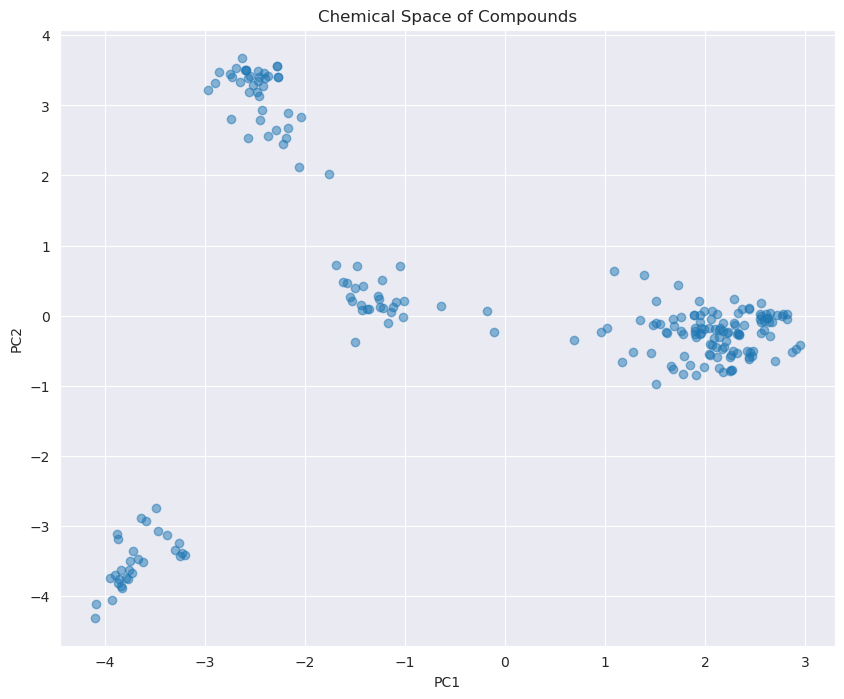

In [23]:

from rdkit.Chem import DataStructs, AllChem
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

outputResults = outputResults.dropna().reset_index(drop=True)
outputResults = outputResults.drop_duplicates(subset=['SMILES']).reset_index(drop=True)

outputResults['mol'] = outputResults['SMILES'].apply(Chem.MolFromSmiles)

fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=1024) for m in substructures['mol']]
fp_array = np.zeros((len(fps), 1024))
for i, fp in enumerate(fps):
    DataStructs.ConvertToNumpyArray(fp, fp_array[i])

pca = PCA(n_components=2)
coords_2d = pca.fit_transform(fp_array)


plt.figure(figsize=(10, 8))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], alpha=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Chemical Space of Compounds')
plt.show()





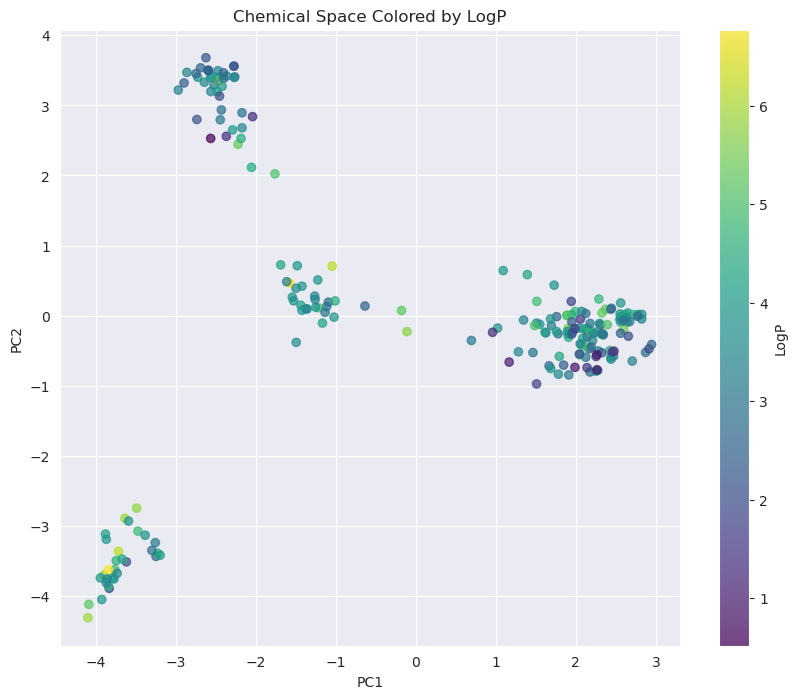

In [24]:
# Calculate LogP
from rdkit.Chem import Descriptors
logp_values = [Descriptors.MolLogP(m) for m in substructures['mol']]
energy_values = substructures['maize (raw)'].tolist()
# Plot colored by LogP
plt.figure(figsize=(10, 8))
plt.scatter(coords_2d[:, 0], coords_2d[:, 1], c=logp_values, cmap='viridis', alpha=0.7)
plt.colorbar(label='LogP')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Chemical Space Colored by LogP')
plt.show()